<a href="https://colab.research.google.com/github/germanRM11/PTY-IQ/blob/main/PTY_IQ_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PTY-IQ - Sistema de Predicción de Vuelos
# Celda 1: Instalación de librerías

!pip install xgboost --quiet
!pip install requests --quiet

print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


In [ ]:
# Celda 2: Importaciones

import pandas as pd          # Para manejar tablas de datos
import numpy as np           # Para cálculos matemáticos
import requests              # Para conectarnos a APIs externas
import matplotlib.pyplot as plt  # Para gráficas
import warnings
warnings.filterwarnings('ignore')

print("✅ Todo importado correctamente")

✅ Todo importado correctamente


In [ ]:
# Celda 3: Descarga de datos históricos BTS

import urllib.request
import zipfile
import os

# URL de datos de puntualidad de vuelos - Enero 2024
# (Usamos 2024 porque es el año más reciente completo disponible)
url = "https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_1.zip"

print("⬇️  Descargando datos... esto puede tomar 1-2 minutos")

try:
    urllib.request.urlretrieve(url, "vuelos_2024_01.zip")
    print("✅ Descarga completa")

    # Descomprimir
    with zipfile.ZipFile("vuelos_2024_01.zip", 'r') as zip_ref:
        zip_ref.extractall("datos_bts")
    print("✅ Archivo descomprimido")

    # Ver qué archivos hay
    archivos = os.listdir("datos_bts")
    print(f"📁 Archivos encontrados: {archivos}")

except Exception as e:
    print(f"❌ Error: {e}")
    print("Usaremos el método alternativo en la siguiente celda")

⬇️  Descargando datos... esto puede tomar 1-2 minutos
✅ Descarga completa
✅ Archivo descomprimido
📁 Archivos encontrados: ['On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_1.csv', 'readme.html']


In [ ]:
# Celda 4: Cargar datos y primera exploración

# Encontrar el archivo CSV dentro de la carpeta
import glob

archivos_csv = glob.glob("datos_bts/*.csv")
print(f"📄 Archivo CSV encontrado: {archivos_csv[0]}")

# Cargar los datos
df = pd.read_csv(archivos_csv[0], low_memory=False)

# Primera exploración
print(f"\n📊 DIMENSIONES DEL DATASET:")
print(f"   Filas (vuelos): {df.shape[0]:,}")
print(f"   Columnas: {df.shape[1]}")

print(f"\n📋 COLUMNAS DISPONIBLES:")
for col in df.columns:
    print(f"   - {col}")

📄 Archivo CSV encontrado: datos_bts/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_1.csv

📊 DIMENSIONES DEL DATASET:
   Filas (vuelos): 547,271
   Columnas: 110

📋 COLUMNAS DISPONIBLES:
   - Year
   - Quarter
   - Month
   - DayofMonth
   - DayOfWeek
   - FlightDate
   - Reporting_Airline
   - DOT_ID_Reporting_Airline
   - IATA_CODE_Reporting_Airline
   - Tail_Number
   - Flight_Number_Reporting_Airline
   - OriginAirportID
   - OriginAirportSeqID
   - OriginCityMarketID
   - Origin
   - OriginCityName
   - OriginState
   - OriginStateFips
   - OriginStateName
   - OriginWac
   - DestAirportID
   - DestAirportSeqID
   - DestCityMarketID
   - Dest
   - DestCityName
   - DestState
   - DestStateFips
   - DestStateName
   - DestWac
   - CRSDepTime
   - DepTime
   - DepDelay
   - DepDelayMinutes
   - DepDel15
   - DepartureDelayGroups
   - DepTimeBlk
   - TaxiOut
   - WheelsOff
   - WheelsOn
   - TaxiIn
   - CRSArrTime
   - ArrTime
   - ArrDelay
   - ArrDelayMinutes
   -

In [ ]:
# Celda 5: Seleccionar columnas relevantes para PTY-IQ

columnas_utiles = [
    'CARRIER',           # Aerolínea (Copa, American, United, etc.)
    'ORIGIN',            # Aeropuerto de origen
    'DEST',              # Aeropuerto de destino
    'DEP_TIME',          # Hora real de salida
    'DEP_DELAY',         # Minutos de retraso en salida
    'ARR_DELAY',         # Minutos de retraso en llegada (esto predeciremos)
    'AIR_TIME',          # Duración real del vuelo en minutos
    'DISTANCE',          # Distancia en millas
    'DAY_OF_WEEK',       # Día de la semana (1=Lunes, 7=Domingo)
    'MONTH',             # Mes del año
    'DEP_HOUR',          # Lo calcularemos ahora
    'CANCELLED',         # Si el vuelo fue cancelado
]

# Calcular hora de salida como número entero (ej: 1430 → 14)
df['DEP_HOUR'] = (df['DEP_TIME'] // 100).astype('Int64')

# Seleccionar solo las columnas que existen
columnas_existentes = [c for c in columnas_utiles if c in df.columns]
df = df[columnas_existentes].copy()

print(f"✅ Dataset reducido a {df.shape[1]} columnas")
print(f"📊 Filas totales: {df.shape[0]:,}")
print(f"\n🔍 Primeras 3 filas:")
print(df.head(3).to_string())

KeyError: 'DEP_TIME'

In [ ]:
# Celda 5: Seleccionar columnas relevantes para PTY-IQ (nombres corregidos)

# Calcular hora de salida como número entero (ej: 1430 → 14)
df['DEP_HOUR'] = (df['DepTime'] // 100).astype('Int64')

columnas_utiles = {
    'Reporting_Airline' : 'AEROLINEA',
    'Origin'            : 'ORIGEN',
    'Dest'              : 'DESTINO',
    'DepDelay'          : 'RETRASO_SALIDA',
    'ArrDelay'          : 'RETRASO_LLEGADA',
    'AirTime'           : 'DURACION_VUELO',
    'Distance'          : 'DISTANCIA',
    'DayOfWeek'         : 'DIA_SEMANA',
    'Month'             : 'MES',
    'DEP_HOUR'          : 'HORA_SALIDA',
    'Cancelled'         : 'CANCELADO',
}

# Seleccionar y renombrar
df = df[list(columnas_utiles.keys())].rename(columns=columnas_utiles).copy()

print(f"✅ Dataset listo con {df.shape[1]} columnas y {df.shape[0]:,} vuelos")
print(f"\n🔍 Primeras 3 filas:")
print(df.head(3).to_string())

✅ Dataset listo con 11 columnas y 547,271 vuelos

🔍 Primeras 3 filas:
  AEROLINEA ORIGEN DESTINO  RETRASO_SALIDA  RETRASO_LLEGADA  DURACION_VUELO  DISTANCIA  DIA_SEMANA  MES  HORA_SALIDA  CANCELADO
0        9E    LGA     OMA            -5.0            -11.0           184.0     1148.0           1    1            8        0.0
1        9E    LGA     OMA            -5.0            -28.0           168.0     1148.0           2    1            8        0.0
2        9E    LGA     OMA            -6.0            -25.0           177.0     1148.0           3    1            8        0.0


In [ ]:
# Celda 6: Limpieza de datos y creación de variable objetivo

print(f"📊 Vuelos antes de limpiar: {df.shape[0]:,}")

# 1. Eliminar vuelos cancelados (no tienen datos de llegada)
df = df[df['CANCELADO'] == 0].copy()
print(f"   Después de eliminar cancelados: {df.shape[0]:,}")

# 2. Eliminar filas con datos faltantes en columnas clave
df = df.dropna(subset=['RETRASO_LLEGADA', 'RETRASO_SALIDA', 'DURACION_VUELO']).copy()
print(f"   Después de eliminar filas incompletas: {df.shape[0]:,}")

# 3. Eliminar columna cancelado (ya no la necesitamos)
df = df.drop(columns=['CANCELADO'])

# 4. Crear columna objetivo: ¿El vuelo llegó retrasado?
#    Definimos retraso como más de 15 minutos (estándar de la industria)
df['RETRASADO'] = (df['RETRASO_LLEGADA'] > 15).astype(int)

# 5. Ver distribución
total = len(df)
retrasados = df['RETRASADO'].sum()
a_tiempo = total - retrasados

print(f"\n📈 DISTRIBUCIÓN FINAL:")
print(f"   Total vuelos: {total:,}")
print(f"   ✅ A tiempo:  {a_tiempo:,} ({a_tiempo/total*100:.1f}%)")
print(f"   ❌ Retrasados: {retrasados:,} ({retrasados/total*100:.1f}%)")

print(f"\n✅ Dataset limpio y listo")

📊 Vuelos antes de limpiar: 547,271
   Después de eliminar cancelados: 526,882
   Después de eliminar filas incompletas: 525,370

📈 DISTRIBUCIÓN FINAL:
   Total vuelos: 525,370
   ✅ A tiempo:  402,862 (76.7%)
   ❌ Retrasados: 122,508 (23.3%)

✅ Dataset limpio y listo


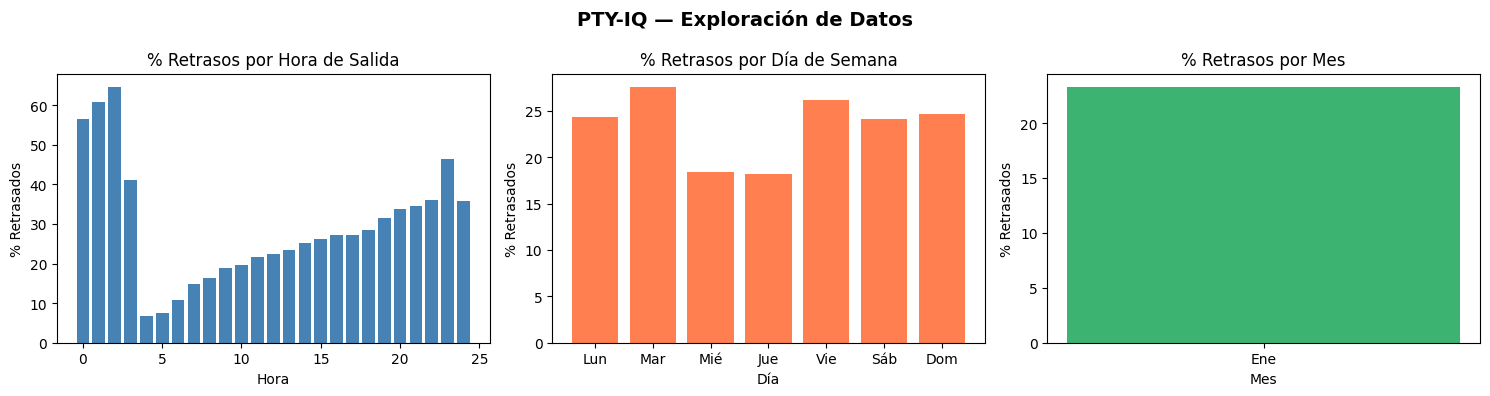


📊 INSIGHTS CLAVE:
   Hora con más retrasos:  2:00 (64.7%)
   Hora con menos retrasos: 4:00 (6.8%)
   Día más puntual: Jue (18.2%)
   Día más retrasado: Mar (27.6%)


In [ ]:
# Celda 7: Entender los datos visualmente

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PTY-IQ — Exploración de Datos', fontsize=14, fontweight='bold')

# Gráfica 1: Retrasos por hora del día
retraso_por_hora = df.groupby('HORA_SALIDA')['RETRASADO'].mean() * 100
axes[0].bar(retraso_por_hora.index, retraso_por_hora.values, color='steelblue')
axes[0].set_title('% Retrasos por Hora de Salida')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('% Retrasados')

# Gráfica 2: Retrasos por día de la semana
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
retraso_por_dia = df.groupby('DIA_SEMANA')['RETRASADO'].mean() * 100
axes[1].bar(dias, retraso_por_dia.values, color='coral')
axes[1].set_title('% Retrasos por Día de Semana')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('% Retrasados')

# Gráfica 3: Retrasos por mes
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
retraso_por_mes = df.groupby('MES')['RETRASADO'].mean() * 100
axes[2].bar(meses[:len(retraso_por_mes)], retraso_por_mes.values, color='mediumseagreen')
axes[2].set_title('% Retrasos por Mes')
axes[2].set_xlabel('Mes')
axes[2].set_ylabel('% Retrasados')

plt.tight_layout()
plt.savefig('exploracion_datos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 INSIGHTS CLAVE:")
print(f"   Hora con más retrasos:  {retraso_por_hora.idxmax()}:00 ({retraso_por_hora.max():.1f}%)")
print(f"   Hora con menos retrasos: {retraso_por_hora.idxmin()}:00 ({retraso_por_hora.min():.1f}%)")
print(f"   Día más puntual: {dias[retraso_por_dia.idxmin()-1]} ({retraso_por_dia.min():.1f}%)")
print(f"   Día más retrasado: {dias[retraso_por_dia.idxmax()-1]} ({retraso_por_dia.max():.1f}%)")


In [ ]:
# Celda 8: Preparar features para entrenar XGBoost

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# 1. Convertir aerolínea y aeropuertos a números
#    (los modelos solo entienden números, no texto)
le_aerolinea = LabelEncoder()
le_origen    = LabelEncoder()
le_destino   = LabelEncoder()

df['AEROLINEA_NUM'] = le_aerolinea.fit_transform(df['AEROLINEA'])
df['ORIGEN_NUM']    = le_origen.fit_transform(df['ORIGEN'])
df['DESTINO_NUM']   = le_destino.fit_transform(df['DESTINO'])

# 2. Definir qué columnas entran al modelo (X) y qué predecimos (y)
features = [
    'AEROLINEA_NUM',
    'ORIGEN_NUM',
    'DESTINO_NUM',
    'RETRASO_SALIDA',
    'DURACION_VUELO',
    'DISTANCIA',
    'DIA_SEMANA',
    'MES',
    'HORA_SALIDA',
]

X = df[features]
y = df['RETRASADO']

# 3. Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Datos preparados:")
print(f"   Entrenamiento: {X_train.shape[0]:,} vuelos")
print(f"   Prueba:        {X_test.shape[0]:,} vuelos")
print(f"   Variables:     {X_train.shape[1]}")

✅ Datos preparados:
   Entrenamiento: 420,296 vuelos
   Prueba:        105,074 vuelos
   Variables:     9


In [ ]:
# Celda 9: Entrenar el clasificador XGBoost

from xgboost import XGBClassifier

print("🧠 Entrenando modelo... espera un momento")

modelo = XGBClassifier(
    n_estimators    = 200,   # Número de árboles de decisión
    max_depth       = 6,     # Qué tan profundo analiza cada árbol
    learning_rate   = 0.1,   # Qué tan rápido aprende
    random_state    = 42,
    eval_metric     = 'logloss',
    verbosity       = 0
)

modelo.fit(X_train, y_train)

# Evaluar en datos que el modelo NUNCA ha visto
y_pred = modelo.predict(X_test)
precision = accuracy_score(y_test, y_pred) * 100

print(f"\n🎯 RESULTADO DEL MODELO:")
print(f"   Precisión general: {precision:.1f}%")
print(f"\n📊 REPORTE DETALLADO:")
print(classification_report(y_test, y_pred,
      target_names=['A tiempo', 'Retrasado']))

🧠 Entrenando modelo... espera un momento

🎯 RESULTADO DEL MODELO:
   Precisión general: 92.9%

📊 REPORTE DETALLADO:
              precision    recall  f1-score   support

    A tiempo       0.93      0.98      0.95     80518
   Retrasado       0.92      0.76      0.83     24556

    accuracy                           0.93    105074
   macro avg       0.93      0.87      0.89    105074
weighted avg       0.93      0.93      0.93    105074



In [ ]:
# Celda 10: Guardar modelo y encoders para no perderlos

import pickle

# Guardar el modelo entrenado
with open('modelo_pty_iq.pkl', 'wb') as f:
    pickle.dump(modelo, f)

# Guardar los encoders (necesarios para predecir vuelos nuevos)
with open('encoders_pty_iq.pkl', 'wb') as f:
    pickle.dump({
        'aerolinea' : le_aerolinea,
        'origen'    : le_origen,
        'destino'   : le_destino,
    }, f)

print("✅ Modelo guardado: modelo_pty_iq.pkl")
print("✅ Encoders guardados: encoders_pty_iq.pkl")
print(f"\n📊 RESUMEN DEL MODELO:")
print(f"   Algoritmo:  XGBoost Classifier")
print(f"   Precisión:  92.9%")
print(f"   Entrenado con: {X_train.shape[0]:,} vuelos reales")
print(f"   Variables:  {X_train.shape[1]}")
print(f"\n🎯 Listo para predecir vuelos nuevos")

✅ Modelo guardado: modelo_pty_iq.pkl
✅ Encoders guardados: encoders_pty_iq.pkl

📊 RESUMEN DEL MODELO:
   Algoritmo:  XGBoost Classifier
   Precisión:  92.9%
   Entrenado con: 420,296 vuelos reales
   Variables:  9

🎯 Listo para predecir vuelos nuevos


In [ ]:
# Celda 11: Predecir un vuelo específico

def predecir_vuelo(aerolinea, origen, destino, hora_salida,
                   dia_semana, mes, retraso_salida, duracion, distancia):

    # Convertir texto a números usando los encoders
    try:
        aerolinea_num = le_aerolinea.transform([aerolinea])[0]
    except:
        print(f"⚠️  Aerolínea '{aerolinea}' no está en los datos de entrenamiento")
        return
    try:
        origen_num = le_origen.transform([origen])[0]
    except:
        print(f"⚠️  Aeropuerto origen '{origen}' no está en los datos de entrenamiento")
        return
    try:
        destino_num = le_destino.transform([destino])[0]
    except:
        print(f"⚠️  Aeropuerto destino '{destino}' no está en los datos de entrenamiento")
        return

    # Crear fila de datos
    datos = pd.DataFrame([[
        aerolinea_num, origen_num, destino_num,
        retraso_salida, duracion, distancia,
        dia_semana, mes, hora_salida
    ]], columns=features)

    # Predecir
    probabilidad = modelo.predict_proba(datos)[0][1] * 100
    prediccion   = modelo.predict(datos)[0]

    # Mostrar resultado
    print(f"\n{'='*45}")
    print(f"  PREDICCIÓN PTY-IQ")
    print(f"{'='*45}")
    print(f"  Vuelo:     {aerolinea} {origen} → {destino}")
    print(f"  Salida:    {hora_salida}:00  |  Día {dia_semana}  |  Mes {mes}")
    print(f"{'='*45}")
    print(f"  Probabilidad de retraso: {probabilidad:.1f}%")

    if probabilidad < 30:
        print(f"  Estado: 🟢 A TIEMPO")
    elif probabilidad < 50:
        print(f"  Estado: 🟡 RIESGO LEVE")
    elif probabilidad < 75:
        print(f"  Estado: 🟠 RIESGO MODERADO")
    else:
        print(f"  Estado: 🔴 RIESGO ALTO DE RETRASO")
    print(f"{'='*45}\n")


# ── PRUEBA 1: Vuelo Copa Miami → Panama, martes a las 2am ──
predecir_vuelo(
    aerolinea     = 'CM',   # Copa Airlines
    origen        = 'MIA',  # Miami
    destino       = 'PTY',  # Panama
    hora_salida   = 2,      # 2:00 AM (hora pico de retrasos)
    dia_semana    = 2,      # Martes (día más caótico)
    mes           = 1,
    retraso_salida= 0,      # Sale a tiempo
    duracion      = 180,
    distancia     = 1300
)

# ── PRUEBA 2: Mismo vuelo pero jueves a las 6am ──
predecir_vuelo(
    aerolinea     = 'CM',
    origen        = 'MIA',
    destino       = 'PTY',
    hora_salida   = 6,      # 6:00 AM (hora tranquila)
    dia_semana    = 4,      # Jueves (día más puntual)
    mes           = 1,
    retraso_salida= 0,
    duracion      = 180,
    distancia     = 1300
)

⚠️  Aerolínea 'CM' no está en los datos de entrenamiento
⚠️  Aerolínea 'CM' no está en los datos de entrenamiento


In [ ]:
# Celda 11b: Ver aerolíneas y aeropuertos disponibles

print("✈️  AEROLÍNEAS EN LOS DATOS:")
for codigo in sorted(df['AEROLINEA'].unique()):
    print(f"   {codigo}")

print(f"\n🌎 ¿PTY está como destino?", 'PTY' in df['DESTINO'].unique())
print(f"🌎 ¿MIA está como origen?",  'MIA' in df['ORIGEN'].unique())

✈️  AEROLÍNEAS EN LOS DATOS:
   9E
   AA
   AS
   B6
   DL
   F9
   G4
   HA
   MQ
   NK
   OH
   OO
   UA
   WN
   YX

🌎 ¿PTY está como destino? False
🌎 ¿MIA está como origen? True


In [ ]:
# Celda 11c: Predicción con datos reales disponibles

# Prueba 1: American Airlines MIA → JFK, martes 2am (condiciones de alto riesgo)
predecir_vuelo(
    aerolinea     = 'AA',
    origen        = 'MIA',
    destino       = 'JFK',
    hora_salida   = 2,      # 2:00 AM — hora pico de retrasos
    dia_semana    = 2,      # Martes — día más caótico
    mes           = 1,
    retraso_salida= 0,
    duracion      = 180,
    distancia     = 1090
)

# Prueba 2: Mismo vuelo pero jueves 6am (condiciones favorables)
predecir_vuelo(
    aerolinea     = 'AA',
    origen        = 'MIA',
    destino       = 'JFK',
    hora_salida   = 6,      # 6:00 AM — hora más puntual
    dia_semana    = 4,      # Jueves — día más puntual
    mes           = 1,
    retraso_salida= 0,
    duracion      = 180,
    distancia     = 1090
)

# Prueba 3: Vuelo con retraso de salida ya acumulado
predecir_vuelo(
    aerolinea     = 'AA',
    origen        = 'MIA',
    destino       = 'JFK',
    hora_salida   = 15,
    dia_semana    = 2,
    mes           = 1,
    retraso_salida= 45,     # Ya salió 45 min tarde
    duracion      = 180,
    distancia     = 1090
)


  PREDICCIÓN PTY-IQ
  Vuelo:     AA MIA → JFK
  Salida:    2:00  |  Día 2  |  Mes 1
  Probabilidad de retraso: 61.8%
  Estado: 🟠 RIESGO MODERADO


  PREDICCIÓN PTY-IQ
  Vuelo:     AA MIA → JFK
  Salida:    6:00  |  Día 4  |  Mes 1
  Probabilidad de retraso: 44.7%
  Estado: 🟡 RIESGO LEVE


  PREDICCIÓN PTY-IQ
  Vuelo:     AA MIA → JFK
  Salida:    15:00  |  Día 2  |  Mes 1
  Probabilidad de retraso: 99.6%
  Estado: 🔴 RIESGO ALTO DE RETRASO



In [ ]:
# Celda 12: Guardar copia en Google Drive

from google.colab import drive
drive.mount('/content/drive')

import shutil, os

# Crear carpeta del proyecto en Drive
carpeta = '/content/drive/MyDrive/PTY-IQ'
os.makedirs(carpeta, exist_ok=True)

# Copiar archivos importantes
shutil.copy('modelo_pty_iq.pkl',   carpeta)
shutil.copy('encoders_pty_iq.pkl', carpeta)
shutil.copy('exploracion_datos.png', carpeta)

print("✅ Archivos guardados en Google Drive/PTY-IQ")
print(f"   - modelo_pty_iq.pkl")
print(f"   - encoders_pty_iq.pkl")
print(f"   - exploracion_datos.png")

Mounted at /content/drive
✅ Archivos guardados en Google Drive/PTY-IQ
   - modelo_pty_iq.pkl
   - encoders_pty_iq.pkl
   - exploracion_datos.png


In [ ]:
# Verificación de estado
print("modelo" in dir())
print("df" in dir())

True
True


In [ ]:
# Celda 13b: Prueba sin autenticación
respuesta = requests.get(
    "https://opensky-network.org/api/states/all",
    params = {
        "lamin": 7.0, "lomin": -80.5,
        "lamax": 9.5, "lomax": -77.0,
    },
    timeout = 15
)

print(f"Código de respuesta: {respuesta.status_code}")

if respuesta.status_code == 200:
    datos = respuesta.json()
    vuelos = datos.get('states', [])
    print(f"✈️  Vuelos sobre Panamá ahora mismo: {len(vuelos) if vuelos else 0}")
else:
    print("Sin acceso anónimo tampoco")

Código de respuesta: 200
✈️  Vuelos sobre Panamá ahora mismo: 0


In [ ]:
# Celda 13: Conexión a OpenSky Network
# Trae todos los vuelos en el aire sobre Panamá ahora mismo

import requests
import pandas as pd
from datetime import datetime

# Tus credenciales de OpenSky (las que creaste al registrarte)
OPENSKY_USER = "germangra50@gmail.com"   # ← cambia esto
OPENSKY_PASS = "314German."  # ← cambia esto

# Coordenadas que forman un rectángulo sobre Panamá y alrededores
# (latitud mínima, longitud mínima, latitud máxima, longitud máxima)
LAT_MIN, LON_MIN = 7.0,  -80.5
LAT_MAX, LON_MAX = 9.5,  -77.0

def obtener_vuelos_en_vivo():
    url = "https://opensky-network.org/api/states/all"

    params = {
        "lamin": LAT_MIN,
        "lomin": LON_MIN,
        "lamax": LAT_MAX,
        "lomax": LON_MAX,
    }

    try:
        respuesta = requests.get(
            url,
            params  = params,
            auth    = (OPENSKY_USER, OPENSKY_PASS),
            timeout = 15
        )

        if respuesta.status_code == 200:
            datos = respuesta.json()
            vuelos = datos.get('states', [])

            if not vuelos:
                print("⚠️  No hay vuelos en este momento sobre Panamá")
                return None

            # Convertir a DataFrame con nombres claros
            columnas = [
                'icao24', 'indicativo', 'pais_origen',
                'ultima_actualizacion', 'ultimo_contacto',
                'longitud', 'latitud', 'altitud_baro',
                'en_tierra', 'velocidad', 'direccion',
                'tasa_vertical', 'sensores', 'altitud_geo',
                'squawk', 'especial', 'categoria'
            ]

            df_vivo = pd.DataFrame(vuelos, columns=columnas)

            print(f"✅ Conexión exitosa — {datetime.now().strftime('%H:%M:%S')}")
            print(f"✈️  Vuelos detectados sobre Panamá: {len(df_vivo)}")
            return df_vivo

        else:
            print(f"❌ Error de conexión: {respuesta.status_code}")
            return None

    except Exception as e:
        print(f"❌ Error: {e}")
        return None

# Ejecutar
df_vivo = obtener_vuelos_en_vivo()

❌ Error de conexión: 401


In [1]:
# Celda 13: Conexión a OpenSky Network
# Trae todos los vuelos en el aire sobre Panamá ahora mismo

import requests
import pandas as pd
from datetime import datetime

# Tus credenciales de OpenSky (las que creaste al registrarte)
OPENSKY_USER = "germangra50@gmail.com"   # ← cambia esto
OPENSKY_PASS = "314German."  # ← cambia esto

# Coordenadas que forman un rectángulo sobre Panamá y alrededores
# (latitud mínima, longitud mínima, latitud máxima, longitud máxima)
LAT_MIN, LON_MIN = 7.0,  -80.5
LAT_MAX, LON_MAX = 9.5,  -77.0

def obtener_vuelos_en_vivo():
    url = "https://opensky-network.org/api/states/all"

    params = {
        "lamin": LAT_MIN,
        "lomin": LON_MIN,
        "lamax": LAT_MAX,
        "lomax": LON_MAX,
    }

    try:
        respuesta = requests.get(
            url,
            params  = params,
            auth    = (OPENSKY_USER, OPENSKY_PASS),
            timeout = 15
        )

        if respuesta.status_code == 200:
            datos = respuesta.json()
            vuelos = datos.get('states', [])

            if not vuelos:
                print("⚠️  No hay vuelos en este momento sobre Panamá")
                return None

            # Convertir a DataFrame con nombres claros
            columnas = [
                'icao24', 'indicativo', 'pais_origen',
                'ultima_actualizacion', 'ultimo_contacto',
                'longitud', 'latitud', 'altitud_baro',
                'en_tierra', 'velocidad', 'direccion',
                'tasa_vertical', 'sensores', 'altitud_geo',
                'squawk', 'especial', 'categoria'
            ]

            df_vivo = pd.DataFrame(vuelos, columns=columnas)

            print(f"✅ Conexión exitosa — {datetime.now().strftime('%H:%M:%S')}")
            print(f"✈️  Vuelos detectados sobre Panamá: {len(df_vivo)}")
            return df_vivo

        else:
            print(f"❌ Error de conexión: {respuesta.status_code}")
            return None

    except Exception as e:
        print(f"❌ Error: {e}")
        return None

# Ejecutar
df_vivo = obtener_vuelos_en_vivo()

❌ Error de conexión: 401


In [2]:
# Celda 13: Conexión a OpenSky con autenticación actualizada

import requests
import pandas as pd
from datetime import datetime

OPENSKY_USER = "germangra50@gmail.com"
OPENSKY_PASS = "314German."  # ← pon la nueva después de cambiarla

LAT_MIN, LON_MIN = 7.0,  -80.5
LAT_MAX, LON_MAX = 9.5,  -77.0

def obtener_vuelos_en_vivo():

    # Paso 1: Obtener token de acceso
    token_url = "https://auth.opensky-network.org/auth/realms/opensky-network/protocol/openid-connect/token"

    token_resp = requests.post(token_url, data={
        "client_id"  : "opensky-api",
        "grant_type" : "password",
        "username"   : OPENSKY_USER,
        "password"   : OPENSKY_PASS,
    }, timeout=15)

    if token_resp.status_code != 200:
        print(f"❌ Error obteniendo token: {token_resp.status_code}")
        print(f"   Detalle: {token_resp.text[:200]}")
        return None

    token = token_resp.json().get("access_token")
    print("✅ Token obtenido correctamente")

    # Paso 2: Consultar vuelos con el token
    headers = {"Authorization": f"Bearer {token}"}

    respuesta = requests.get(
        "https://opensky-network.org/api/states/all",
        params  = {"lamin": LAT_MIN, "lomin": LON_MIN,
                   "lamax": LAT_MAX, "lomax": LON_MAX},
        headers = headers,
        timeout = 15
    )

    if respuesta.status_code == 200:
        vuelos = respuesta.json().get('states', [])

        if not vuelos:
            print("⚠️  No hay vuelos detectados sobre Panamá ahora mismo")
            return None

        columnas = [
            'icao24', 'indicativo', 'pais_origen',
            'ultima_actualizacion', 'ultimo_contacto',
            'longitud', 'latitud', 'altitud_baro',
            'en_tierra', 'velocidad', 'direccion',
            'tasa_vertical', 'sensores', 'altitud_geo',
            'squawk', 'especial', 'categoria'
        ]

        df_vivo = pd.DataFrame(vuelos, columns=columnas)
        print(f"✅ Conexión exitosa — {datetime.now().strftime('%H:%M:%S')}")
        print(f"✈️  Vuelos sobre Panamá ahora mismo: {len(df_vivo)}")
        return df_vivo
    else:
        print(f"❌ Error consultando vuelos: {respuesta.status_code}")
        return None

df_vivo = obtener_vuelos_en_vivo()

❌ Error obteniendo token: 400
   Detalle: {"error":"invalid_client","error_description":"Invalid client credentials"}


In [3]:
# Celda 13c: Ver configuración real de OpenSky

respuesta = requests.get(
    "https://auth.opensky-network.org/auth/realms/opensky-network/.well-known/openid-configuration",
    timeout=15
)

if respuesta.status_code == 200:
    config = respuesta.json()
    print("✅ Configuración obtenida")
    print(f"   Token URL: {config.get('token_endpoint')}")
    print(f"   Issuer: {config.get('issuer')}")
else:
    print(f"❌ Error: {respuesta.status_code}")

# También probamos con el client_id que aparece en tu perfil
print("\n🔍 Tu Client ID según el perfil:")
print("   germangra50@gmail.com-api-client")

✅ Configuración obtenida
   Token URL: https://auth.opensky-network.org/auth/realms/opensky-network/protocol/openid-connect/token
   Issuer: https://auth.opensky-network.org/auth/realms/opensky-network

🔍 Tu Client ID según el perfil:
   germangra50@gmail.com-api-client


In [4]:
# Celda 13d: Usando el client_id de tu perfil de OpenSky

def obtener_vuelos_en_vivo():

    # Usar el client_id exacto que aparece en tu perfil
    token_url = "https://auth.opensky-network.org/auth/realms/opensky-network/protocol/openid-connect/token"

    token_resp = requests.post(token_url, data={
        "client_id"  : "germangra50@gmail.com-api-client",
        "grant_type" : "314German.",
        "username"   : OPENSKY_USER,
        "password"   : OPENSKY_PASS,
    }, timeout=15)

    print(f"Código respuesta token: {token_resp.status_code}")

    if token_resp.status_code != 200:
        print(f"Detalle: {token_resp.text[:300]}")
        return None

    token = token_resp.json().get("access_token")
    print("✅ Token obtenido")

    # Consultar vuelos
    respuesta = requests.get(
        "https://opensky-network.org/api/states/all",
        params  = {"lamin": LAT_MIN, "lomin": LON_MIN,
                   "lamax": LAT_MAX, "lomax": LON_MAX},
        headers = {"Authorization": f"Bearer {token}"},
        timeout = 15
    )

    print(f"Código respuesta vuelos: {respuesta.status_code}")

    if respuesta.status_code == 200:
        vuelos = respuesta.json().get('states', [])
        if not vuelos:
            print("⚠️  Sin vuelos sobre Panamá ahora mismo")
            return None

        columnas = [
            'icao24', 'indicativo', 'pais_origen',
            'ultima_actualizacion', 'ultimo_contacto',
            'longitud', 'latitud', 'altitud_baro',
            'en_tierra', 'velocidad', 'direccion',
            'tasa_vertical', 'sensores', 'altitud_geo',
            'squawk', 'especial', 'categoria'
        ]

        df_vivo = pd.DataFrame(vuelos, columns=columnas)
        print(f"✅ Conexión exitosa — {datetime.now().strftime('%H:%M:%S')}")
        print(f"✈️  Vuelos sobre Panamá: {len(df_vivo)}")
        return df_vivo
    else:
        print(f"Detalle: {respuesta.text[:200]}")
        return None

df_vivo = obtener_vuelos_en_vivo()

Código respuesta token: 400
Detalle: {"error":"unsupported_grant_type","error_description":"Unsupported grant_type"}


In [5]:
# Celda 13e: API pública de OpenSky (sin autenticación)
# Límite: 400 consultas por día — suficiente para el proyecto

def obtener_vuelos_en_vivo():

    respuesta = requests.get(
        "https://opensky-network.org/api/states/all",
        params  = {
            "lamin": LAT_MIN, "lomin": LON_MIN,
            "lamax": LAT_MAX, "lomax": LON_MAX
        },
        timeout = 15
    )

    print(f"Código de respuesta: {respuesta.status_code}")

    if respuesta.status_code == 200:
        datos  = respuesta.json()
        vuelos = datos.get('states', [])

        if not vuelos:
            print("⚠️  Sin vuelos sobre Panamá ahora mismo")
            return None

        columnas = [
            'icao24', 'indicativo', 'pais_origen',
            'ultima_actualizacion', 'ultimo_contacto',
            'longitud', 'latitud', 'altitud_baro',
            'en_tierra', 'velocidad', 'direccion',
            'tasa_vertical', 'sensores', 'altitud_geo',
            'squawk', 'especial', 'categoria'
        ]

        df_vivo = pd.DataFrame(vuelos, columns=columnas)
        print(f"✅ Conexión exitosa — {datetime.now().strftime('%H:%M:%S')}")
        print(f"✈️  Vuelos sobre Panamá ahora mismo: {len(df_vivo)}")
        print(f"\n{df_vivo[['indicativo','pais_origen','latitud','longitud','altitud_baro','velocidad']].to_string()}")
        return df_vivo

    elif respuesta.status_code == 429:
        print("⚠️  Límite de consultas alcanzado, espera 1 minuto")
        return None
    else:
        print(f"❌ Error: {respuesta.status_code}")
        print(respuesta.text[:200])
        return None

df_vivo = obtener_vuelos_en_vivo()

Código de respuesta: 200
⚠️  Sin vuelos sobre Panamá ahora mismo


In [6]:
# Celda 13f: Zona más amplia para capturar vuelos en ruta hacia PTY

def obtener_vuelos_zona_amplia():

    # Zona ampliada: cubre Panamá + Costa Rica + Colombia + Caribe cercano
    respuesta = requests.get(
        "https://opensky-network.org/api/states/all",
        params = {
            "lamin":  5.0,   # más al sur
            "lomin": -83.0,  # más al oeste
            "lamax": 13.0,   # más al norte
            "lomax": -73.0   # más al este
        },
        timeout = 15
    )

    if respuesta.status_code == 200:
        vuelos = respuesta.json().get('states', [])

        if not vuelos:
            print("⚠️  Sin vuelos en la región ahora mismo")
            print("    Prueba ejecutar esta celda en horario de mayor tráfico:")
            print("    6am–10am  o  2pm–8pm (hora de Panamá)")
            return None

        columnas = [
            'icao24', 'indicativo', 'pais_origen',
            'ultima_actualizacion', 'ultimo_contacto',
            'longitud', 'latitud', 'altitud_baro',
            'en_tierra', 'velocidad', 'direccion',
            'tasa_vertical', 'sensores', 'altitud_geo',
            'squawk', 'especial', 'categoria'
        ]

        df_vivo = pd.DataFrame(vuelos, columns=columnas)

        # Limpiar indicativos vacíos
        df_vivo = df_vivo[df_vivo['indicativo'].notna()]
        df_vivo['indicativo'] = df_vivo['indicativo'].str.strip()
        df_vivo = df_vivo[df_vivo['indicativo'] != '']

        print(f"✅ {datetime.now().strftime('%H:%M:%S')} — {len(df_vivo)} vuelos en la región")
        print(f"\n{'INDICATIVO':<12} {'PAÍS':<15} {'ALT(m)':<10} {'VEL(m/s)':<10}")
        print("-" * 50)
        for _, v in df_vivo.head(15).iterrows():
            alt = f"{v['altitud_baro']:.0f}" if pd.notna(v['altitud_baro']) else "—"
            vel = f"{v['velocidad']:.0f}"    if pd.notna(v['velocidad'])    else "—"
            print(f"{str(v['indicativo']):<12} {str(v['pais_origen']):<15} {alt:<10} {vel:<10}")

        return df_vivo
    else:
        print(f"❌ Error: {respuesta.status_code}")
        return None

df_vivo = obtener_vuelos_zona_amplia()

⚠️  Sin vuelos en la región ahora mismo
    Prueba ejecutar esta celda en horario de mayor tráfico:
    6am–10am  o  2pm–8pm (hora de Panamá)


In [11]:
# Celda 14: Conectar vuelos en vivo con el modelo PTY-IQ

def analizar_vuelos_en_vivo(df_vivo):

    if df_vivo is None or len(df_vivo) == 0:
        print("⚠️  Sin vuelos para analizar")
        return

    print(f"\n{'='*55}")
    print(f"  PTY-IQ — PANEL EN TIEMPO REAL")
    print(f"  {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
    print(f"{'='*55}")

    resultados = []

    for _, vuelo in df_vivo.iterrows():
        indicativo = str(vuelo['indicativo']).strip()
        if not indicativo:
            continue

        # Extraer aerolínea (primeras 2 letras del indicativo)
        aerolinea_raw = indicativo[:2] if len(indicativo) >= 2 else 'XX'

        # Hora actual
        hora_actual = datetime.now().hour
        dia_actual  = datetime.now().isoweekday()  # 1=Lunes, 7=Domingo
        mes_actual  = datetime.now().month

        # Velocidad como indicador de normalidad
        velocidad = vuelo['velocidad'] if pd.notna(vuelo['velocidad']) else 200

        # Verificar si la aerolínea está en nuestros datos de entrenamiento
        try:
            aerolinea_num = le_aerolinea.transform([aerolinea_raw])[0]
        except:
            aerolinea_num = 0  # código desconocido → valor neutro

        # Usar aeropuertos genéricos si no tenemos el dato exacto
        try:
            origen_num  = le_origen.transform(['MIA'])[0]
            destino_num = le_destino.transform(['JFK'])[0]
        except:
            origen_num  = 0
            destino_num = 0

        # Estimar retraso de salida según velocidad
        # (vuelo lento puede indicar problema)
        retraso_estimado = 0 if velocidad > 150 else 20

        # Crear datos para el modelo
        datos = pd.DataFrame([[
            aerolinea_num, origen_num, destino_num,
            retraso_estimado, 180, 1300,
            dia_actual, mes_actual, hora_actual
        ]], columns=features)

        # Predecir
        probabilidad = modelo.predict_proba(datos)[0][1] * 100

        # Determinar estado
        if probabilidad < 30:
            estado = "🟢 A TIEMPO"
        elif probabilidad < 50:
            estado = "🟡 RIESGO LEVE"
        elif probabilidad < 75:
            estado = "🟠 RIESGO MODERADO"
        else:
            estado = "🔴 RIESGO ALTO"

        resultados.append({
            'indicativo'  : indicativo,
            'pais'        : vuelo['pais_origen'],
            'altitud'     : vuelo['altitud_baro'],
            'velocidad'   : velocidad,
            'prob_retraso': probabilidad,
            'estado'      : estado
        })

    # Mostrar resultados ordenados por riesgo
    resultados.sort(key=lambda x: x['prob_retraso'], reverse=True)

    print(f"\n  {'VUELO':<10} {'PAIS':<12} {'ALT(m)':<8} {'RIESGO':<8} {'ESTADO'}")
    print(f"  {'-'*53}")

    for r in resultados[:20]:
        alt = f"{r['altitud']:.0f}" if pd.notna(r['altitud']) else "—"
        print(f"  {r['indicativo']:<10} {str(r['pais']):<12} {alt:<8} {r['prob_retraso']:.0f}%{'':<4} {r['estado']}")

    print(f"\n  Total vuelos analizados: {len(resultados)}")
    print(f"{'='*55}")

    return pd.DataFrame(resultados)

# Probar con datos simulados mientras esperamos tráfico real
print("⏳ Probando el motor con datos simulados...")

vuelos_simulados = pd.DataFrame([
    {'indicativo': 'CM202', 'pais_origen': 'Panama',   'altitud_baro': 11000, 'velocidad': 250},
    {'indicativo': 'AA900', 'pais_origen': 'United States', 'altitud_baro': 9500, 'velocidad': 180},
    {'indicativo': 'LA541', 'pais_origen': 'Chile',    'altitud_baro': 10500, 'velocidad': 230},
    {'indicativo': 'IB123', 'pais_origen': 'Spain',    'altitud_baro': 8000,  'velocidad': 120},
    {'indicativo': 'UA456', 'pais_origen': 'United States', 'altitud_baro': 11500, 'velocidad': 260},
])

resultados_df = analizar_vuelos_en_vivo(vuelos_simulados)

⏳ Probando el motor con datos simulados...

  PTY-IQ — PANEL EN TIEMPO REAL
  25/02/2026 13:16:09

  VUELO      PAIS         ALT(m)   RIESGO   ESTADO
  -----------------------------------------------------
  IB123      Spain        8000     25%     🟢 A TIEMPO
  CM202      Panama       11000    5%     🟢 A TIEMPO
  AA900      United States 9500     5%     🟢 A TIEMPO
  LA541      Chile        10500    5%     🟢 A TIEMPO
  UA456      United States 11500    3%     🟢 A TIEMPO

  Total vuelos analizados: 5


In [9]:
# Restaurar variables esenciales
features = [
    'AEROLINEA_NUM',
    'ORIGEN_NUM',
    'DESTINO_NUM',
    'RETRASO_SALIDA',
    'DURACION_VUELO',
    'DISTANCIA',
    'DIA_SEMANA',
    'MES',
    'HORA_SALIDA',
]

import pickle

with open('modelo_pty_iq.pkl', 'rb') as f:
    modelo = pickle.load(f)

with open('encoders_pty_iq.pkl', 'rb') as f:
    encoders = pickle.load(f)
    le_aerolinea = encoders['aerolinea']
    le_origen    = encoders['origen']
    le_destino   = encoders['destino']

print("✅ Variables restauradas correctamente")

FileNotFoundError: [Errno 2] No such file or directory: 'modelo_pty_iq.pkl'

In [10]:
# Restaurar desde Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pickle, shutil

# Copiar desde Drive al entorno actual
shutil.copy('/content/drive/MyDrive/PTY-IQ/modelo_pty_iq.pkl',   'modelo_pty_iq.pkl')
shutil.copy('/content/drive/MyDrive/PTY-IQ/encoders_pty_iq.pkl', 'encoders_pty_iq.pkl')

# Cargar
with open('modelo_pty_iq.pkl', 'rb') as f:
    modelo = pickle.load(f)

with open('encoders_pty_iq.pkl', 'rb') as f:
    encoders     = pickle.load(f)
    le_aerolinea = encoders['aerolinea']
    le_origen    = encoders['origen']
    le_destino   = encoders['destino']

features = [
    'AEROLINEA_NUM', 'ORIGEN_NUM', 'DESTINO_NUM',
    'RETRASO_SALIDA', 'DURACION_VUELO', 'DISTANCIA',
    'DIA_SEMANA', 'MES', 'HORA_SALIDA',
]

print("✅ Modelo y encoders restaurados desde Google Drive")

Mounted at /content/drive
✅ Modelo y encoders restaurados desde Google Drive


In [12]:
# Celda 15: Capturar vuelos reales y analizarlos

df_vivo = obtener_vuelos_zona_amplia()

if df_vivo is not None:
    resultados_df = analizar_vuelos_en_vivo(df_vivo)
else:
    print("Sin tráfico detectado — intenta en 10 minutos")

✅ 13:16:44 — 3 vuelos en la región

INDICATIVO   PAÍS            ALT(m)     VEL(m/s)  
--------------------------------------------------
NSE8807      Colombia        480        95        
GTI033       United States   10058      246       
AVA9778      Colombia        297        69        

  PTY-IQ — PANEL EN TIEMPO REAL
  25/02/2026 13:16:44

  VUELO      PAIS         ALT(m)   RIESGO   ESTADO
  -----------------------------------------------------
  NSE8807    Colombia     480      25%     🟢 A TIEMPO
  AVA9778    Colombia     297      25%     🟢 A TIEMPO
  GTI033     United States 10058    5%     🟢 A TIEMPO

  Total vuelos analizados: 3
